In [141]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

**Data Preparation**

In [142]:
!curl -L -o bank.csv https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
 39 80876   39 31845    0     0  63838      0  0:00:01 --:--:--  0:00:01 63945
100 80876  100 80876    0     0   142k      0 --:--:-- --:--:-- --:--:--  142k


In [143]:
df = pd.read_csv('bank.csv')
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [144]:
df.describe()

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
count,1462.000000,1281.000000,1462.000000,1462.000000,1462.000000
mean,2.031464,59886.273224,2.976744,0.506108,0.619015
std,1.449717,15070.140389,1.681564,0.288465,0.485795
min,0.000000,13929.000000,0.000000,0.000000,0.000000
25%,1.000000,49698.000000,2.000000,0.262500,0.000000
50%,2.000000,60148.000000,3.000000,0.510000,1.000000
75%,3.000000,69639.000000,4.000000,0.750000,1.000000
max,9.000000,109899.000000,11.000000,1.000000,1.000000


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [146]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [147]:
numerical = df.select_dtypes(include=[np.number]).columns
df[numerical] = df[numerical].fillna(0.0)

In [148]:
categorical = df.select_dtypes(include=['object']).columns
df[categorical] = df[categorical].fillna('NA')

In [149]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [150]:
df['industry'].value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64

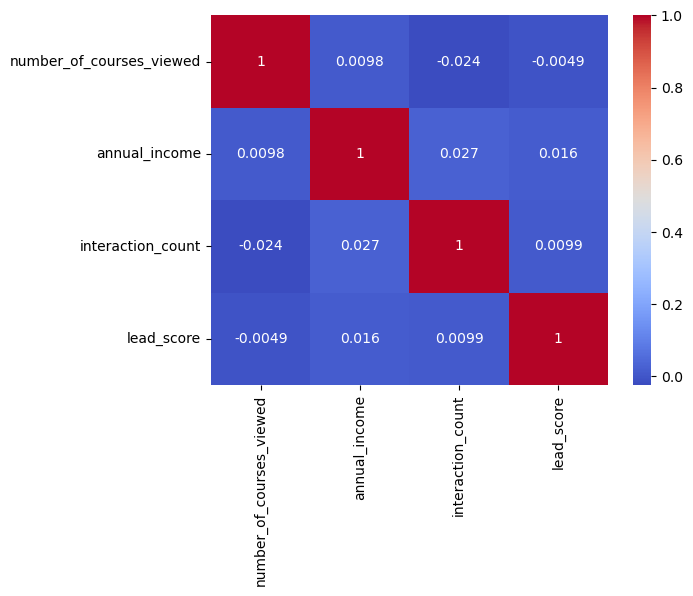

In [151]:
df_numerical = df[numerical].drop(columns = ['converted'])
corr = df_numerical.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

**Setting up the validation framework**

In [152]:

# first split test
df_full_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["converted"]
)

# then split train/val
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42, stratify=df_full_train["converted"]
)

In [153]:

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [154]:
y_train = df_train["converted"].astype(int).values
y_val   = df_val["converted"].astype(int).values
y_test  = df_test["converted"].astype(int).values



del df_train['converted']
del df_val['converted']
del df_test['converted']

In [155]:
df_train

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score
0,social_media,other,4,53556.0,self_employed,africa,2,0.18
1,referral,healthcare,3,66872.0,unemployed,NA,3,0.03
2,events,healthcare,3,60375.0,student,australia,9,0.30
3,NA,manufacturing,3,51271.0,unemployed,europe,3,0.60
4,social_media,healthcare,1,57537.0,student,south_america,2,0.28
...,...,...,...,...,...,...,...,...
871,NA,other,1,71395.0,student,NA,5,0.83
872,NA,education,3,89042.0,employed,asia,4,0.75
873,paid_ads,other,2,0.0,unemployed,north_america,4,0.18
874,social_media,finance,2,43899.0,self_employed,australia,2,0.39


**Feature Importance**

In [156]:
mi_scores = {}
for c in categorical:
    s = mutual_info_score(df_train[c],y_train).round(2)
    mi_scores[c] = s

In [157]:
mi_scores

{'lead_source': np.float64(0.03),
 'industry': np.float64(0.01),
 'employment_status': np.float64(0.01),
 'location': np.float64(0.0)}

**One-Hot-Encoding**

In [158]:
dv = DictVectorizer(sparse=False)
train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

In [159]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [160]:
w0 = model.intercept_[0]

In [161]:
w = model.coef_[0].round(3)
w

array([-0.   , -0.001,  0.016, -0.001, -0.005, -0.101, -0.017,  0.027,
       -0.012, -0.012, -0.001, -0.028, -0.039, -0.01 ,  0.301,  0.052,
       -0.007, -0.041, -0.019, -0.098,  0.086, -0.013, -0.   , -0.013,
       -0.011, -0.016, -0.011,  0.002, -0.022, -0.022,  0.446])

In [162]:
y_predict = model.predict_proba(X_val)[:,1]

In [163]:
convert_decision = (y_predict >= 0.5)

In [164]:
acc = (y_val == convert_decision).mean()
acc                                        

np.float64(0.7303754266211604)

In [165]:
results ={}
for f in ['industry','employment_status','lead_score']:
    df_train_new = df_train.drop(columns=[f])
    df_val_new = df_val.drop(columns=[f])
    train_dict_new = df_train_new.to_dict(orient='records')
    val_dict_new = df_val_new.to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X_train_new = dv.fit_transform(train_dict_new)
    X_val_new = dv.transform(val_dict_new)
   
    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train_new, y_train)
    y_pred_new = model.predict_proba(X_val_new)[:, 1]
    acc_new = (y_val == (y_pred_new >= 0.5)).mean()

    diff = acc - acc_new
    results[f] = round(diff, 4)

In [166]:
results

{'industry': np.float64(0.0),
 'employment_status': np.float64(-0.0034),
 'lead_score': np.float64(0.0)}

In [168]:
c_results = {}
for c in [0.01,0.1,1,10,100]:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train,y_train)
    y_predict = model.predict_proba(X_val)[:,1]
    convert_decision = (y_predict >= 0.5)
    acc_c = (y_val == convert_decision).mean()
    c_results[c] = acc_c
c_results

{0.01: np.float64(0.7337883959044369),
 0.1: np.float64(0.7303754266211604),
 1: np.float64(0.7303754266211604),
 10: np.float64(0.7303754266211604),
 100: np.float64(0.7303754266211604)}